In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load original CIFAR-10 data again
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Before normalization:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Min:", X_test.min())
print("Max:", X_test.max())

Before normalization:
X_train: (50000, 32, 32, 3)
X_test : (10000, 32, 32, 3)
Min: 0
Max: 255


In [2]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Labels
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

print("After normalization:")
print("X_test shape:", X_test.shape)
print("X_test dtype:", X_test.dtype)
print("Min:", X_test.min())
print("Max:", X_test.max())

After normalization:
X_test shape: (10000, 32, 32, 3)
X_test dtype: float32
Min: 0.0
Max: 1.0


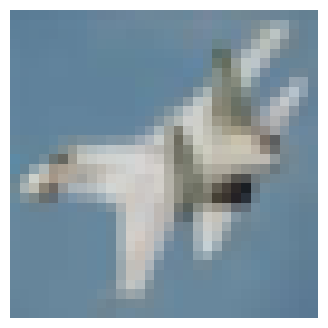

In [3]:
index = 10

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index])
plt.axis("off")
plt.show()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Flatten(input_shape=(32, 32, 3)),

    Dense(512, activation="relu"),
    Dropout(0.3),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

C:\Users\Nithyanandan\tensorflow_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.2446 - loss: 2.0474 - val_accuracy: 0.3315 - val_loss: 1.8596
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3062 - loss: 1.8935 - val_accuracy: 0.3582 - val_loss: 1.7938
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3273 - loss: 1.8394 - val_accuracy: 0.3710 - val_loss: 1.7759
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3386 - loss: 1.8141 - val_accuracy: 0.3765 - val_loss: 1.7495
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3491 - loss: 1.7831 - val_accuracy: 0.3831 - val_loss: 1.7087
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3570 - loss: 1.7684 - val_accuracy: 0.3939 - val_loss: 1.7006
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3650 - loss: 1.7451 - val_accuracy: 0.4054 - val_loss: 1.6770
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3713 - loss: 1.7303 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


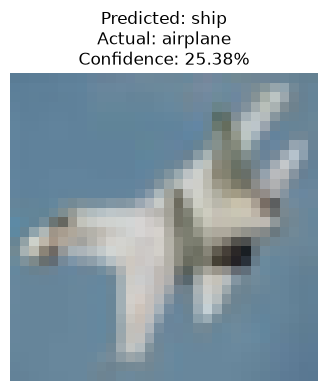

In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

index = 10

predicted_class = class_names[y_pred[index]]
actual_class = class_names[y_test[index]]

confidence = predictions[index][y_pred[index]] * 100

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index])
plt.axis("off")

plt.title(
    f"Predicted: {predicted_class}\n"
    f"Actual: {actual_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()